# Journal de bord

Copier-coller les cellules suivantes comme canevas pour chaque journée.

## 📅 Journal de bord – Jour 1 (10/07/2025)

### 🔧 Étapes / Actions réalisées
- Aquisition, Lecture du brief et préparation de l'environnement
- Setup du repo git pour suivre l'exercice depuis plusieurs poste
- Analyse rapide des données

### 📝 Observations / Difficultés
- Le volume de données me pose probleme pour le travail avec git. Je recherche une solution plus compacte je sais que gzip permet de diminuer de + de 80% les csv donc je vais mettre en place un pipe de compression/decompression

In [1]:
import gzip
with open('dataset/2016_01.csv', 'rb') as f_in, gzip.open('dataset/2016_01.csv.gz', 'wb') as f_out:
    f_out.writelines(f_in)

In [ ]:
import gzip
import os

for m in range(1, 13):
    fname = f'dataset/2016_{m:02d}.csv'
    gzname = f'dataset/2016_{m:02d}.csv.gz'
    if os.path.exists(fname):
        with open(fname, 'rb') as f_in, gzip.open(gzname, 'wb') as f_out:
            f_out.writelines(f_in)
        print(f"Compressé : {fname} -> {gzname}")
    else:
        print(f"Fichier non trouvé : {fname}")

### ✅ Prochaines étapes
- Lire les description des colonnes pour identifier colonnes inutiles ou non éthiques
- Utiliser missingno pour visualiser l'état des données : à première vue il ya beaucoup de données inutiles, des données manquantes, peut etre des doublons
[Projet Git : ](https://github.com/ResidentMario/missingno)
- Trouver le bon moyen pour agréger (ou non ) les 12 fichiers de données


## 📅 Journal de bord – Jour 2 (12/07/2025)

### 🔧 Étapes / Actions réalisées
- Setup projet sur ordinateur de travail
- Installation et tests de visualisation missingno : ça confirme un travail potentiel de nettoyage

- Je me penche sur la description des colonnes des donnéee (à partir du fichier 01 pour le moment.)
- J'utilise csv2table dans vscode pour une analyse visuelle des données pour le moment
- les données d'aeroport sont redondentes : etat name ... etc. Il y a moyen de réduire le nombre de colonne qui plus est ça prends du poids (ou il faudrait un modèle relationnel)
- Je tente de monter les donnnées brutes dans sqllite pour faire des analyses. et voir si ça me permet de contenir toutes les données dans moins de 100 mo (contrainte git)
- Je décris toutes les colonnes dans un fichier json à partir de la base du Bureau of Transportation Statistics (BTS) des États-Unis (dataset_description.json) . Il me servira à filtrer et typer les données pas la suite
- On a bien 68 colonnes décrites. Je continue l'analyse des colonnes pour voir celles qui sont inutiles ou non éthiques

In [ ]:
import pandas as pd
import sqlite3
import glob

# Connexion à la base SQLite (créée si elle n'existe pas)
conn = sqlite3.connect('flights.db')

# Liste tous les fichiers .csv.gz du dossier dataset/
files = glob.glob('dataset/*.csv.gz')

# for m in range(1, 13):
for file in files:
    print(f"Traitement de {file}")
    # file = f'dataset/2016_{m:02d}.csv.gz'
    # Lecture du fichier gzip (pandas gère nativement)
    df = pd.read_csv(file, dtype=str, compression='gzip', on_bad_lines='skip')  # Ignore les lignes corrompues
   
    
    # Conversion des colonnes numériques (optionnel, à affiner selon le schéma)
    # for col in ['DAY_OF_WEEK', 'AIRLINE_ID', 'FL_NUM', 'ORIGIN_AIRPORT_ID', 'DEST_AIRPORT_ID']:
    #     if col in df.columns:
    #         df[col] = pd.to_numeric(df[col], errors='coerce')
    # Conversion des booléens
    # for col in ['CANCELLED', 'DIVERTED', 'DEP_DEL15', 'ARR_DEL15']:
    #     if col in df.columns:
    #         df[col] = df[col].astype('float').astype('Int64')
    # Conversion des dates
    # if 'FL_DATE' in df.columns:
    #     df['FL_DATE'] = pd.to_datetime(df['FL_DATE'], errors='coerce')
    # Insertion dans la base (création de la table si besoin)
    df.to_sql('flights_raw', conn, if_exists='append', index=False)

conn.close()
print("Import terminé.")

## SQLITE n'est pas super adapté, je vais utiliser des fichier parquet pour faire le nettoyage et l'analyse des données

Création d'une fonction pour convertir les gzip en parquet pour voir si ça permet d'enviseager une meilleur utilisation des données dans le notebook
Mais Pb le fichier 4 contient des incohérences

In [ ]:
import pandas as pd
import json
import glob
import os

def csv_gz_to_parquet(json_path, csv_dir, output_dir):
    # Charge la description des colonnes
    with open(json_path, 'r', encoding='utf-8') as f:
        desc = json.load(f)

    # Liste des colonnes à garder et mapping type
    keep_cols = []
    type_map = {}
    for cat in desc.values():
        for col in cat:
            if col["keep"]:
                keep_cols.append(col["name"])
                type_map[col["name"]] = col["type"]

    # Crée le dossier de sortie si besoin
    os.makedirs(output_dir, exist_ok=True)

    # Parcourt les fichiers csv.gz
    for file in glob.glob(os.path.join(csv_dir, "*.csv.gz")):
        print(f"Traitement de {file}")
        df = pd.read_csv(file, compression='gzip', dtype=str, low_memory=False)
        # Filtre les colonnes
        df = df[[col for col in keep_cols if col in df.columns]]
        # Conversion des types
        for col, typ in type_map.items():
            if col in df.columns:
                if typ == "int":
                    df[col] = pd.to_numeric(df[col], errors='coerce').astype('Int64')
                elif typ == "float":
                    df[col] = pd.to_numeric(df[col], errors='coerce')
                elif typ == "bool":
                    df[col] = df[col].astype('float').astype('Int64').astype('boolean')
                elif typ == "date":
                    df[col] = pd.to_datetime(df[col], errors='coerce')
                # str : rien à faire
        # Enregistre en parquet
        base = os.path.splitext(os.path.basename(file))[0]
        out_path = os.path.join(output_dir, f"{base}.parquet")
        df.to_parquet(out_path, index=False)
        print(f"Fichier sauvegardé : {out_path}")

# Exemple d'appel :
csv_gz_to_parquet(
    json_path="data/dataset_description.json",
    csv_dir="dataset",
    output_dir="parquet"
)

# Convertion du dataset en fichiers .parquet et avec filtrages des colonnes utiles
- J'utilise la fonction csv_gz_to_parquet_v2 pour convertir l'ensemble des fichiers gzip en parquet. Cette fonction lit le fichier JSON de description des colonnes, filtre les colonnes inutiles, et convertit les types de données selon la description.
- Cela rempli les données ambigu avec des valeurs par défaut (par exemple, 0 pour les entiers, NaN pour les flottants, etc.)
- J'ai choisi de ne pas me pencher plus en profondeur sur les 11 lignes du pack 4 qui ne sont pas interprétable sans les reconstruire. Je les ignore mais j'ai loggué un fichier csv pour les retrouver si besoin.

In [ ]:
import pandas as pd
import json
import glob
import os
import csv
import gzip

def csv_gz_to_parquet_v2(json_path, csv_dir, output_dir):

    # Charge la description des colonnes
    with open(json_path, 'r', encoding='utf-8') as f:
        desc = json.load(f)

    keep_cols = []
    type_map = {}
    for cat in desc.values():
        for col in cat:
            if col["keep"]:
                keep_cols.append(col["name"])
                type_map[col["name"]] = col["type"]

    os.makedirs(output_dir, exist_ok=True)

    for file in glob.glob(os.path.join(csv_dir, "*.csv.gz")):
        print(f"🔄 Traitement de {file}")
        try:
            valid_rows = []
            invalid_rows = []

            with gzip.open(file, 'rt', encoding='utf-8', errors='replace') as f_in:
                reader = csv.reader(f_in, delimiter=',', quotechar='"')
                header = next(reader)  # utilise le header réel du fichier
                expected_col_count = len(header)

                for i, row in enumerate(reader, start=2):  # start=2 car header = ligne 1
                    if len(row) == expected_col_count:
                        valid_rows.append(row)
                    else:
                        invalid_rows.append({
                            "line_number": i,
                            "columns": len(row),
                            "row": row
                        })

            df = pd.DataFrame(valid_rows, columns=header)

            # Sélectionne uniquement les colonnes nécessaires
            df = df[[col for col in keep_cols if col in df.columns]]

            for col, typ in type_map.items():
                if col in df.columns:
                    if typ == "int":
                        df[col] = pd.to_numeric(df[col].replace('', pd.NA), errors='coerce').astype('Int64')
                    elif typ == "float":
                        df[col] = pd.to_numeric(df[col].replace('', pd.NA), errors='coerce')
                    elif typ == "bool":
                        df[col] = pd.to_numeric(df[col].replace('', pd.NA), errors='coerce') \
                                    .astype('Int64').astype('boolean')
                    elif typ == "date":
                        df[col] = pd.to_datetime(df[col].replace('', pd.NaT), errors='coerce')

            base = os.path.splitext(os.path.basename(file))[0]
            out_path = os.path.join(output_dir, f"{base}.parquet")
            df.to_parquet(out_path, index=False)
            print(f"✅ Parquet sauvegardé : {out_path}")

            if invalid_rows:
                log_path = os.path.join(output_dir, f"{base}_ignored_lines.csv")
                with open(log_path, 'w', newline='', encoding='utf-8') as log_file:
                    writer = csv.writer(log_file)
                    writer.writerow(["line_number", "columns", "row"])
                    for entry in invalid_rows:
                        writer.writerow([entry["line_number"], entry["columns"], json.dumps(entry["row"])])
                print(f"⚠️ Lignes ignorées sauvegardées dans : {log_path} ({len(invalid_rows)} lignes)")

        except Exception as e:
            print(f"❌ Erreur lors du traitement de {file} : {e}")
            
# Exemple d'appel :
csv_gz_to_parquet_v2(
    json_path="data/dataset_description.json",
    csv_dir="./data/raw",
    output_dir="./data/processed"
)

🔄 Traitement de dataset\2016_01.csv.gz
✅ Parquet sauvegardé : parquet\2016_01.csv.parquet
🔄 Traitement de dataset\2016_02.csv.gz
✅ Parquet sauvegardé : parquet\2016_02.csv.parquet
🔄 Traitement de dataset\2016_03.csv.gz
✅ Parquet sauvegardé : parquet\2016_03.csv.parquet
🔄 Traitement de dataset\2016_04.csv.gz
✅ Parquet sauvegardé : parquet\2016_04.csv.parquet
⚠️ Lignes ignorées sauvegardées dans : parquet\2016_04.csv_ignored_lines.csv (11 lignes)
🔄 Traitement de dataset\2016_05.csv.gz
✅ Parquet sauvegardé : parquet\2016_05.csv.parquet
🔄 Traitement de dataset\2016_06.csv.gz
✅ Parquet sauvegardé : parquet\2016_06.csv.parquet
🔄 Traitement de dataset\2016_07.csv.gz
✅ Parquet sauvegardé : parquet\2016_07.csv.parquet
🔄 Traitement de dataset\2016_08.csv.gz
✅ Parquet sauvegardé : parquet\2016_08.csv.parquet
🔄 Traitement de dataset\2016_09.csv.gz
✅ Parquet sauvegardé : parquet\2016_09.csv.parquet
🔄 Traitement de dataset\2016_10.csv.gz
✅ Parquet sauvegardé : parquet\2016_10.csv.parquet
🔄 Traitemen

In [8]:
# Création d'une fonction pour détecter les erreurs

import csv
import gzip

def analyser_structure_csv(file_path, expected_columns=65, max_samples=10):
    nb_total = 0
    nb_invalid = 0
    exemples_invalides = []

    with gzip.open(file_path, 'rt', encoding='utf-8', errors='replace') as f:
        reader = csv.reader(f, delimiter=',', quotechar='"')
        for i, row in enumerate(reader, start=1):
            nb_total += 1
            if len(row) != expected_columns:
                nb_invalid += 1
                if len(exemples_invalides) < max_samples:
                    exemples_invalides.append({
                        "ligne": i,
                        "nb_colonnes": len(row),
                        "contenu": row
                    })

    pourcentage = round((nb_invalid / nb_total) * 100, 4)
    print("📊 Résumé d’analyse du fichier CSV :")
    print(f" - Lignes totales      : {nb_total}")
    print(f" - Lignes invalides    : {nb_invalid}")
    print(f" - Pourcentage invalide: {pourcentage} %")
    print()
    print("🧪 Exemples de lignes invalides :")
    for exemple in exemples_invalides:
        print(f" - Ligne {exemple['ligne']} ({exemple['nb_colonnes']} colonnes)")
        print(f"   ↪ {exemple['contenu'][:5]} ...\n")

    return {
        "nb_total": nb_total,
        "nb_invalides": nb_invalid,
        "pourcentage": pourcentage,
        "exemples": exemples_invalides
    }

# Utilisation :
fichier = "./data/raw/2016_04.csv.gz"
rapport = analyser_structure_csv(fichier)


📊 Résumé d’analyse du fichier CSV :
 - Lignes totales      : 479957
 - Lignes invalides    : 11
 - Pourcentage invalide: 0.0023 %

🧪 Exemples de lignes invalides :
 - Ligne 88688 (42 colonnes)
   ↪ ['2016', '2', '4', '7', '4'] ...

 - Ligne 121012 (75 colonnes)
   ↪ ['2016', '1', '3', '25', '5'] ...

 - Ligne 385888 (49 colonnes)
   ↪ ['2016', '2', '4', '22', '5'] ...

 - Ligne 386249 (83 colonnes)
   ↪ ['2016', '1', '3', '11', '5'] ...

 - Ligne 388291 (78 colonnes)
   ↪ ['2016', '2', '4', '4', '1'] ...

 - Ligne 389371 (72 colonnes)
   ↪ ['2016', '1', '3', '15', '2'] ...

 - Ligne 389548 (81 colonnes)
   ↪ ['2016', '2', '4', '4', '1'] ...

 - Ligne 453858 (97 colonnes)
   ↪ ['2016', '1', '3', '4', '5'] ...

 - Ligne 454123 (40 colonnes)
   ↪ ['2016', '2', '4', '29', '5'] ...

 - Ligne 455029 (58 colonnes)
   ↪ ['2016', '1', '3', '28', '1'] ...



### 📝 Observations / Difficultés
- Lors de la boucle d'injection des données, je m'apercois que certains fichiers ont une structure différentes. par exemple le fichier 04 contient 75 colonnes au lieu de 65 pour les autres
- ex ligne 121011 du pack 4 : ..."Colorado",82,12266,1226603,31453,"IAH",","Santa Ana, CA","CA","06"... il y a un découpage incorect des colonnes
- Choix de UNIQUE_CARRIER comme colonne de référence pour les compagnies aériennes. Il est stable dans le temps et permet de suivre les changements de code IATA

### ✅ Prochaines étapes
- Assembler les données dans un format agrégé afin de passer au nettoyage et analyse

## 📅 Journal de bord – Jour 4 (14/07/2025)

### 🔧 Étapes / Actions réalisées
- Assemblage des fichiers parquets

Charge tous les fichiers .parquet du dossier,
Les concatène en un seul DataFrame,
Sauvegarde le résultat dans ./dataset/all.parquet.

In [17]:
import pandas as pd
import glob
import os

def combine_parquet_files(parquet_dir, output_file):
    files = glob.glob(os.path.join(parquet_dir, "*.parquet"))
    print(f"Fichiers trouvés : {len(files)}")
    dfs = []
    for file in files:
        print(f"Lecture de {file}")
        dfs.append(pd.read_parquet(file))
    df_all = pd.concat(dfs, ignore_index=True)
    print(f"Nombre total de lignes : {len(df_all)}")
    df_all.to_parquet(output_file, index=False)
    print(f"✅ Fichier combiné sauvegardé : {output_file}")

# Utilisation :
combine_parquet_files(
    parquet_dir="./parquet",
    output_file="./all.parquet"
)

Fichiers trouvés : 12
Lecture de ./parquet\2016_01.csv.parquet
Lecture de ./parquet\2016_02.csv.parquet
Lecture de ./parquet\2016_03.csv.parquet
Lecture de ./parquet\2016_04.csv.parquet
Lecture de ./parquet\2016_05.csv.parquet
Lecture de ./parquet\2016_06.csv.parquet
Lecture de ./parquet\2016_07.csv.parquet
Lecture de ./parquet\2016_08.csv.parquet
Lecture de ./parquet\2016_09.csv.parquet
Lecture de ./parquet\2016_10.csv.parquet
Lecture de ./parquet\2016_11.csv.parquet
Lecture de ./parquet\2016_12.csv.parquet
Nombre total de lignes : 5635973
✅ Fichier combiné sauvegardé : ./all.parquet


=> 5 635 973 entrées, 68 colonnes réduire à 43 colonnes qui semblent utiles
=> 11 lignes corrompus dans le pack 4, ignorées

### 📝 Observations / Difficultés
- On a un processus de nettoyage à variable pour commmencer le nettoyage exploration des données

### ✅ Prochaines étapes
- 

## 📅 Journal de bord – Jour 5 (21/07/2025)

### 🔧 Étapes / Actions réalisées
- 

### 📝 Observations / Difficultés
- 

### ✅ Prochaines étapes
- 

## Generation des parquets (Equivalents des données brutes) qui sont légèrement plus léger que les gzip

In [ ]:
import pandas as pd
import glob
import os
import csv
import gzip

# Conversion brute des fichiers .csv.gz en .parquet (toutes colonnes), log des lignes invalides

def convert_csv_gz_to_parquet_full_with_log(csv_dir, output_dir):
    os.makedirs(output_dir, exist_ok=True)
    for file in glob.glob(os.path.join(csv_dir, "*.csv.gz")):
        print(f"Traitement de {file}")
        valid_rows = []
        invalid_rows = []
        with gzip.open(file, 'rt', encoding='utf-8', errors='replace') as f_in:
            reader = csv.reader(f_in, delimiter=',', quotechar='"')
            header = next(reader)
            expected_col_count = len(header)
            for i, row in enumerate(reader, start=2):
                if len(row) == expected_col_count:
                    valid_rows.append(row)
                else:
                    invalid_rows.append({
                        "line_number": i,
                        "columns": len(row),
                        "row": row
                    })
        df = pd.DataFrame(valid_rows, columns=header)
        base = os.path.splitext(os.path.basename(file))[0]
        out_path = os.path.join(output_dir, f"{base}.parquet")
        df.to_parquet(out_path, index=False)
        print(f"✅ Parquet sauvegardé : {out_path}")
        if invalid_rows:
            log_path = os.path.join(output_dir, f"{base}_ignored_lines.csv")
            with open(log_path, 'w', newline='', encoding='utf-8') as log_file:
                writer = csv.writer(log_file)
                writer.writerow(["line_number", "columns", "row"])
                for entry in invalid_rows:
                    writer.writerow([entry["line_number"], entry["columns"], str(entry["row"])])
            print(f"⚠️ Lignes ignorées sauvegardées dans : {log_path} ({len(invalid_rows)} lignes)")

# Utilisation :
convert_csv_gz_to_parquet_full_with_log(
    csv_dir="data/raw",
    output_dir="data/processed"
)


# Création du fichier combiné pour appliquer des nettoyages

In [ ]:
import pandas as pd
import glob
import os

# 2. Concaténation des fichiers .parquet en un seul all_full.parquet et chargement du DataFrame
def combine_parquet_full_files(parquet_dir, output_file):
    files = glob.glob(os.path.join(parquet_dir, "*.parquet"))
    print(f"Fichiers trouvés : {len(files)}")
    dfs = []
    for file in files:
        print(f"Lecture de {file}")
        dfs.append(pd.read_parquet(file))
    df_all = pd.concat(dfs, ignore_index=True)
    print(f"Nombre total de lignes : {len(df_all)}")
    df_all.to_parquet(output_file, index=False)
    print(f"✅ Fichier combiné sauvegardé : {output_file}")
    return df_all

# Utilisation :
df_all_full = combine_parquet_full_files(
    parquet_dir="data/processed",
    output_file="data/processed/all_full.parquet"
)

In [4]:
import pandas as pd

# 3. Analyse des doublons sur le DataFrame agrégé
# (Suppose que df_all_full est déjà chargé)
nb_total = len(df_all_full)
nb_duplicates = df_all_full.duplicated().sum()
print(f"Nombre total de lignes : {nb_total}")
print(f"Nombre de doublons : {nb_duplicates}")
print(f"Pourcentage de doublons : {nb_duplicates / nb_total * 100:.2f} %")

# Afficher quelques exemples de doublons
if nb_duplicates > 0:
    print("Exemples de doublons :")
    print(df_all_full[df_all_full.duplicated()].head())


Nombre total de lignes : 5635973
Nombre de doublons : 117117
Pourcentage de doublons : 2.08 %
Exemples de doublons :
         YEAR QUARTER MONTH DAY_OF_MONTH DAY_OF_WEEK     FL_DATE  \
1437524  2016       1     3           26           6  2016-03-26   
1437525  2016       1     3           26           6  2016-03-26   
1437526  2016       1     3           26           6  2016-03-26   
1437527  2016       1     3           26           6  2016-03-26   
1437528  2016       1     3           26           6  2016-03-26   

        UNIQUE_CARRIER AIRLINE_ID CARRIER TAIL_NUM  ... DISTANCE_GROUP  \
1437524             AS      19930      AS   N323AS  ...              5   
1437525             AS      19930      AS   N579AS  ...              8   
1437526             AS      19930      AS   N614AS  ...              7   
1437527             AS      19930      AS   N487AS  ...              5   
1437528             AS      19930      AS   N462AS  ...              7   

        CARRIER_DELAY WEATHER

In [5]:
# Exporter les doublons dans un fichier CSV pour analyse : le Volume de 2% de doublon m'interroge

duplicates_df = df_all_full[df_all_full.duplicated()]
duplicates_df.to_csv("data/processed/all_full_duplicates.csv", index=False)
print(f"✅ Fichier CSV des doublons exporté : all_full_duplicates.csv ({len(duplicates_df)} lignes)")


✅ Fichier CSV des doublons exporté : all_full_duplicates.csv (117117 lignes)


In [6]:
# Afficher des exemples de doublons avec leur index source et doublon

duplicated_mask = df_all_full.duplicated(keep=False)
duplicated_df = df_all_full[duplicated_mask]

# Grouper par toutes les colonnes pour trouver les groupes de doublons
for _, group in duplicated_df.groupby(list(df_all_full.columns)):
    if len(group) > 1:
        print("--- Exemple de doublon ---")
        print(group.head(2))  # Affiche la source et le doublon
        print()
        break  # Affiche seulement le premier exemple


--- Exemple de doublon ---
         YEAR QUARTER MONTH DAY_OF_MONTH DAY_OF_WEEK     FL_DATE  \
1319335  2016       1     3            1           2  2016-03-01   
1440272  2016       1     3            1           2  2016-03-01   

        UNIQUE_CARRIER AIRLINE_ID CARRIER TAIL_NUM  ... DISTANCE_GROUP  \
1319335             B6      20409      B6   N178JB  ...              5   
1440272             B6      20409      B6   N178JB  ...              5   

        CARRIER_DELAY WEATHER_DELAY NAS_DELAY SECURITY_DELAY  \
1319335                                                        
1440272                                                        

        LATE_AIRCRAFT_DELAY FIRST_DEP_TIME TOTAL_ADD_GTIME LONGEST_ADD_GTIME    
1319335                                                                         
1440272                                                                         

[2 rows x 65 columns]



In [ ]:
df_duplicated_sample = group.head(20)
df_duplicated_sample.to_csv("data/processed/df_duplicated_sample.csv", index=False)

## Aucun doute possible on a bien 2% de doublons dans les données :
- On a notre dataset de référence type raw : on a juste retiré 11 lignes inexpoitable sur l'ensemble des 5 635 973 entrées
- => A partir du fichier *parquet all_full.parquet* (agregation), on va appliquer le nettoyage puis ne garder que les colonnes que l'on a sélectionné dans dataset_description.json

Création du fichier nettoyé et filtré

In [35]:
import pandas as pd
import json

# Charger le DataFrame agrégé
all_full_path = "data/processed/all_full.parquet"
df_all_full = pd.read_parquet(all_full_path)

print(f"Avant suppression des doublons : {df_all_full.shape}")
df_all_full = df_all_full.drop_duplicates()
print(f"Après suppression des doublons : {df_all_full.shape}")

# On drop les lignes où la cible n'existe pas (ARR_DEL15) et on s'assure du type
df_all_full = df_all_full[df_all_full['ARR_DEL15'].notna() & (df_all_full['ARR_DEL15'].astype(str).str.strip() != "")]
df_all_full['ARR_DEL15'] = df_all_full['ARR_DEL15'].astype('bool')

# On filtre les colonnes que l'on garde sur le jeu total avec uniquement les colonnes du brief
# Charger la liste des colonnes à garder et leur typage depuis dataset_description.json
with open("data/dataset_description.json", "r", encoding="utf-8") as f:
    desc = json.load(f)

keep_cols = []
type_map = {}
for cat in desc.values():
    for col in cat:
        if col.get("is_describe_in_topic"):
            keep_cols.append(col["name"])
            type_map[col["name"]] = col["type"]

cols_to_keep = [col for col in keep_cols if col in df_all_full.columns]
df_clean = df_all_full[cols_to_keep].copy()

# Appliquer le typage selon type_map
for col, typ in type_map.items():
    if col in df_clean.columns:
        if typ == "int":
            df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce').astype('Int64')
        elif typ == "float":
            df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')
        elif typ == "bool":
            df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce').astype('Int64').astype('boolean')
        elif typ == "date":
            df_clean[col] = pd.to_datetime(df_clean[col], errors='coerce')
        # str : rien à faire

print(f"Colonnes conservées : {len(cols_to_keep)}")
print(f"Shape du DataFrame nettoyé : {df_clean.shape}")

clean_path = "data/processed/all_from_subject.parquet"
df_clean.to_parquet(clean_path, index=False)
print(f"✅ Fichier nettoyé, typé et sans doublons sauvegardé : {clean_path}")

Avant suppression des doublons : (5635973, 65)
Après suppression des doublons : (5518856, 65)
Colonnes conservées : 49
Shape du DataFrame nettoyé : (5440148, 49)
✅ Fichier nettoyé, typé et sans doublons sauvegardé : data/processed/all_from_subject.parquet


# on fait un sample de 100 000 lignes pour faire les tests de nettoyage et d'analyse


In [36]:
df_sample = df_clean.sample(n=100_000, random_state=42)

In [37]:
# ON se fait une petite sortie de controle de 1000 lignes en csv
sample_1000 = df_sample.sample(n=1000, random_state=42)
sample_1000.to_csv("data/processed/sample_1000.csv", index=False)


In [38]:
df_sample.describe()

,DAY_OF_WEEK,FL_DATE,AIRLINE_ID,FL_NUM,ORIGIN_AIRPORT_ID,ORIGIN_AIRPORT_SEQ_ID,ORIGIN_CITY_MARKET_ID,ORIGIN_WAC,DEST_AIRPORT_ID,DEST_AIRPORT_SEQ_ID,...,DEP_DELAY_NEW,DEP_DELAY_GROUP,TAXI_OUT,TAXI_IN,ARR_DELAY,ARR_DELAY_NEW,ARR_DELAY_GROUP,CRS_ELAPSED_TIME,ACTUAL_ELAPSED_TIME,AIR_TIME
count,100000.0,100000,100000.0,100000.0,100000.0,100000.0,100000.0,100000.0,100000.0,100000.0,...,100000.00000,100000.0,100000.00000,100000.000000,100000.000000,100000.000000,100000.0,100000.000000,100000.000000,100000.000000
mean,3.92849,2016-07-04 02:19:27.839999744,19896.37731,2068.12463,12678.42593,1267845.47806,31718.12289,55.98388,12680.39171,1268042.05535,...,11.98825,-0.00654,16.15726,7.470040,3.629880,12.008840,-0.26439,145.492600,140.054180,116.426880
min,1.0,2016-01-01 00:00:00,19393.0,1.0,10135.0,1013503.0,30070.0,1.0,10135.0,1013503.0,...,0.00000,-2.0,1.00000,1.000000,-83.000000,0.000000,-2.0,18.000000,16.000000,8.000000
25%,2.0,2016-04-04 00:00:00,19790.0,710.0,11292.0,1129202.0,30599.0,34.0,11292.0,1129202.0,...,0.00000,-1.0,11.00000,4.000000,-14.000000,0.000000,-1.0,88.000000,84.000000,62.000000
50%,4.0,2016-07-06 00:00:00,19805.0,1634.0,12889.0,1288903.0,31453.0,53.0,12889.0,1288903.0,...,0.00000,-1.0,14.00000,6.000000,-6.000000,0.000000,-1.0,126.000000,121.000000,97.000000
75%,6.0,2016-10-02 00:00:00,20304.0,2838.0,14027.0,1402702.0,32467.0,82.0,14027.0,1402702.0,...,6.00000,0.0,19.00000,9.000000,6.000000,6.000000,0.0,178.000000,173.000000,148.000000
max,7.0,2016-12-31 00:00:00,21171.0,7439.0,16218.0,1621801.0,35991.0,93.0,16218.0,1621801.0,...,1474.00000,12.0,151.00000,250.000000,1508.000000,1508.000000,12.0,683.000000,677.000000,656.000000
std,1.989989,NaN,378.800671,1692.643898,1534.969288,153496.635033,1282.816874,26.965951,1532.981759,153297.881513,...,39.54722,2.088483,8.81732,5.770344,42.822788,39.341027,2.225147,76.442756,75.630234,73.456052


In [22]:
df_sample.info()

<class 'pandas.core.frame.DataFrame'>
Index: 100000 entries, 4886315 to 4631449
Data columns (total 49 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   DAY_OF_WEEK            100000 non-null  Int64         
 1   FL_DATE                100000 non-null  datetime64[ns]
 2   UNIQUE_CARRIER         100000 non-null  object        
 3   AIRLINE_ID             100000 non-null  Int64         
 4   CARRIER                100000 non-null  object        
 5   TAIL_NUM               100000 non-null  object        
 6   FL_NUM                 100000 non-null  Int64         
 7   ORIGIN_AIRPORT_ID      100000 non-null  Int64         
 8   ORIGIN_AIRPORT_SEQ_ID  100000 non-null  Int64         
 9   ORIGIN_CITY_MARKET_ID  100000 non-null  Int64         
 10  ORIGIN                 100000 non-null  object        
 11  ORIGIN_CITY_NAME       100000 non-null  object        
 12  ORIGIN_STATE_ABR       100000 non-null  ob

In [39]:
df = df_sample.apply(pd.to_numeric, errors='ignore')
df.dtypes

C:\Users\ol4\AppData\Local\Temp\ipykernel_52136\2916466986.py:1: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df = df_sample.apply(pd.to_numeric, errors='ignore')


DAY_OF_WEEK                Int64
FL_DATE                    int64
UNIQUE_CARRIER            object
AIRLINE_ID                 Int64
CARRIER                   object
TAIL_NUM                  object
FL_NUM                     Int64
ORIGIN_AIRPORT_ID          Int64
ORIGIN_AIRPORT_SEQ_ID      Int64
ORIGIN_CITY_MARKET_ID      Int64
ORIGIN                    object
ORIGIN_CITY_NAME          object
ORIGIN_STATE_ABR          object
ORIGIN_STATE_FIPS          int64
ORIGIN_STATE_NM           object
ORIGIN_WAC                 Int64
DEST_AIRPORT_ID            Int64
DEST_AIRPORT_SEQ_ID        Int64
DEST_CITY_MARKET_ID        Int64
DEST                      object
DEST_CITY_NAME            object
DEST_STATE_ABR            object
DEST_STATE_FIPS            int64
DEST_STATE_NM             object
DEST_WAC                   Int64
CRS_DEP_TIME               int64
DEP_TIME                   int64
DEP_DELAY                float64
DEP_DELAY_NEW            float64
DEP_DEL15                boolean
DEP_DELAY_

In [20]:
df.head()

,DAY_OF_WEEK,FL_DATE,UNIQUE_CARRIER,AIRLINE_ID,CARRIER,TAIL_NUM,FL_NUM,ORIGIN_AIRPORT_ID,ORIGIN_AIRPORT_SEQ_ID,ORIGIN_CITY_MARKET_ID,...,ARR_DELAY_NEW,ARR_DEL15,ARR_DELAY_GROUP,ARR_TIME_BLK,CANCELLED,CANCELLATION_CODE,DIVERTED,CRS_ELAPSED_TIME,ACTUAL_ELAPSED_TIME,AIR_TIME
4886315,2,1479168000000000000,WN,19393,WN,N769SW,2944,13198,1319801,33198,...,17.0,True,1,1400-1459,False,,False,175.0,196.0,175.0
1335746,3,1458691200000000000,B6,20409,B6,N507JB,1534,15304,1530402,33195,...,0.0,False,-1,2200-2259,False,,False,166.0,159.0,139.0
971601,3,1457481600000000000,EV,20366,EV,N146PQ,5064,13367,1336703,33367,...,0.0,False,-1,0800-0859,False,,False,118.0,114.0,94.0
2127632,5,1464307200000000000,OO,20304,OO,N727SK,5526,11292,1129202,30325,...,0.0,False,-1,0900-0959,False,,False,157.0,149.0,128.0
5515678,4,1480550400000000000,UA,19977,UA,N67812,1456,12266,1226603,31453,...,0.0,False,-2,1300-1359,False,,False,260.0,245.0,227.0


In [27]:
print(df["CANCELLATION_CODE"].unique())

['' 'C' 'B' 'A']


In [21]:
# Afficher uniquement les colonnes de type object (texte)
object_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"Colonnes de type object : {object_cols}")
df[object_cols].head()

Colonnes de type object : ['UNIQUE_CARRIER', 'CARRIER', 'TAIL_NUM', 'ORIGIN', 'ORIGIN_CITY_NAME', 'ORIGIN_STATE_ABR', 'ORIGIN_STATE_NM', 'DEST', 'DEST_CITY_NAME', 'DEST_STATE_ABR', 'DEST_STATE_NM', 'DEP_TIME_BLK', 'ARR_TIME_BLK', 'CANCELLATION_CODE']


,UNIQUE_CARRIER,CARRIER,TAIL_NUM,ORIGIN,ORIGIN_CITY_NAME,ORIGIN_STATE_ABR,ORIGIN_STATE_NM,DEST,DEST_CITY_NAME,DEST_STATE_ABR,DEST_STATE_NM,DEP_TIME_BLK,ARR_TIME_BLK,CANCELLATION_CODE
4886315,WN,WN,N769SW,MCI,"Kansas City, MO",MO,Missouri,BOS,"Boston, MA",MA,Massachusetts,1000-1059,1400-1459,
1335746,B6,B6,N507JB,TPA,"Tampa, FL",FL,Florida,BDL,"Hartford, CT",CT,Connecticut,1900-1959,2200-2259,
971601,EV,EV,N146PQ,MLI,"Moline, IL",IL,Illinois,ATL,"Atlanta, GA",GA,Georgia,0600-0659,0800-0859,
2127632,OO,OO,N727SK,DEN,"Denver, CO",CO,Colorado,SMF,"Sacramento, CA",CA,California,0700-0759,0900-0959,
5515678,UA,UA,N67812,IAH,"Houston, TX",TX,Texas,SFO,"San Francisco, CA",CA,California,1100-1159,1300-1359,


Colonnes de type object : ['UNIQUE_CARRIER', 'CARRIER', 'TAIL_NUM', 'ORIGIN', 'ORIGIN_CITY_NAME', 'ORIGIN_STATE_ABR', 'ORIGIN_STATE_NM', 'DEST', 'DEST_CITY_NAME', 'DEST_STATE_ABR', 'DEST_STATE_NM', 'DEP_TIME_BLK', 'ARR_TIME_BLK', 'CANCELLATION_CODE']

df.describe()

In [31]:
df.describe()

,DAY_OF_WEEK,FL_DATE,AIRLINE_ID,FL_NUM,ORIGIN_AIRPORT_ID,ORIGIN_AIRPORT_SEQ_ID,ORIGIN_CITY_MARKET_ID,ORIGIN_STATE_FIPS,ORIGIN_WAC,DEST_AIRPORT_ID,...,WHEELS_ON,TAXI_IN,CRS_ARR_TIME,ARR_TIME,ARR_DELAY,ARR_DELAY_NEW,ARR_DELAY_GROUP,CRS_ELAPSED_TIME,ACTUAL_ELAPSED_TIME,AIR_TIME
count,100000.0,1.000000e+05,100000.0,100000.0,100000.0,100000.0,100000.0,100000.000000,100000.0,100000.0,...,98759.000000,98759.000000,100000.000000,98759.000000,98534.000000,98534.000000,98534.0,100000.000000,98534.000000,98534.000000
mean,3.93164,1.467557e+18,19899.4787,2074.65822,12681.14179,1268117.0525,31715.04608,25.664970,55.92562,12673.87506,...,1464.721403,7.478103,1489.741230,1469.516206,3.830982,12.159113,-0.257475,145.507640,140.224613,116.584144
std,1.986682,9.041243e+15,380.516092,1695.446804,1533.19502,153319.213845,1278.686566,16.663534,27.022284,1533.551576,...,530.304514,5.706834,515.901277,534.417235,43.783891,40.379950,2.237018,76.672511,75.873809,73.753919
min,1.0,1.451606e+18,19393.0,1.0,10135.0,1013503.0,30070.0,1.000000,1.0,10135.0,...,1.000000,1.000000,1.000000,1.000000,-89.000000,0.000000,-2.0,21.000000,18.000000,8.000000
25%,2.0,1.459642e+18,19790.0,714.0,11292.0,1129202.0,30599.0,12.000000,34.0,11292.0,...,1048.000000,4.000000,1105.000000,1052.000000,-14.000000,0.000000,-1.0,88.000000,84.000000,62.000000
50%,4.0,1.467763e+18,19805.0,1637.0,12889.0,1288903.0,31453.0,24.000000,53.0,12889.0,...,1506.000000,6.000000,1520.000000,1510.000000,-6.000000,0.000000,-1.0,126.000000,121.000000,97.000000
75%,6.0,1.475280e+18,20304.0,2851.0,14057.0,1405702.0,32467.0,40.000000,82.0,14027.0,...,1912.000000,9.000000,1919.000000,1916.000000,6.000000,6.000000,0.0,178.000000,173.000000,148.000000
max,7.0,1.483142e+18,21171.0,7439.0,16218.0,1621801.0,35991.0,78.000000,93.0,16218.0,...,2400.000000,163.000000,2359.000000,2400.000000,1488.000000,1488.000000,12.0,700.000000,769.000000,682.000000


In [ ]:
# df_clean.head()
# on ne garde que ces 2 colonne : CRS_ARR_TIME et ARR_TIME et ARR_DEL15
df_sample_filtered = df_sample[["CRS_ARR_TIME", "ARR_TIME", "ARR_DEL15"]].copy()
df_sample_filtered = df_sample_filtered[df_sample_filtered["ARR_DEL15"] == True]
# convertion en numerique
df_sample_filtered["CRS_ARR_TIME"] = pd.to_numeric(df_sample_filtered["CRS_ARR_TIME"], errors='coerce')
df_sample_filtered["ARR_TIME"] = pd.to_numeric(df_sample_filtered["ARR_TIME"], errors
df_sample_filtered.head()

,CRS_ARR_TIME,ARR_TIME,ARR_DEL15
4886315,1430,1447,True
5516957,1645,1957,True
2908062,1715,1730,True
3017158,830,850,True
1836405,1635,1704,True


In [5]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5518856 entries, 0 to 5635972
Data columns (total 49 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   DAY_OF_WEEK            Int64         
 1   FL_DATE                datetime64[ns]
 2   UNIQUE_CARRIER         object        
 3   AIRLINE_ID             Int64         
 4   CARRIER                object        
 5   TAIL_NUM               object        
 6   FL_NUM                 Int64         
 7   ORIGIN_AIRPORT_ID      Int64         
 8   ORIGIN_AIRPORT_SEQ_ID  Int64         
 9   ORIGIN_CITY_MARKET_ID  Int64         
 10  ORIGIN                 object        
 11  ORIGIN_CITY_NAME       object        
 12  ORIGIN_STATE_ABR       object        
 13  ORIGIN_STATE_FIPS      object        
 14  ORIGIN_STATE_NM        object        
 15  ORIGIN_WAC             Int64         
 16  DEST_AIRPORT_ID        Int64         
 17  DEST_AIRPORT_SEQ_ID    Int64         
 18  DEST_CITY_MARKET_ID    Int6

In [ ]:
import pandas as pd
import json

# Charger le DataFrame agrégé
all_full_path = "data/processed/all_full.parquet"
df_all_full = pd.read_parquet(all_full_path)

print(f"Avant suppression des doublons : {df_all_full.shape}")
df_all_full = df_all_full.drop_duplicates()
print(f"Après suppression des doublons : {df_all_full.shape}")

# On drop les lignes où la cible n'existe pas ; DEP_DEL15
if 'ARR_DEL15' in df_all_full.columns:
    df_all_full = df_all_full[df_all_full['ARR_DEL15'].notna()]
    print(f"Après suppression des lignes sans ARR_DEL15 : {df_all_full.shape}")

# Charger la liste des colonnes à garder et leur typage depuis dataset_description.json
with open("data/dataset_description.json", "r", encoding="utf-8") as f:
    desc = json.load(f)

keep_cols = []
type_map = {}
for cat in desc.values():
    for col in cat:
        if col["keep"]:
            keep_cols.append(col["name"])
            type_map[col["name"]] = col["type"]

cols_to_keep = [col for col in keep_cols if col in df_all_full.columns]
df_clean = df_all_full[cols_to_keep].copy()

# Appliquer le typage selon type_map
for col, typ in type_map.items():
    if col in df_clean.columns:
        if typ == "int":
            df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce').astype('Int64')
        elif typ == "float":
            df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')
        elif typ == "bool":
            df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce').astype('Int64').astype('boolean')
        elif typ == "date":
            df_clean[col] = pd.to_datetime(df_clean[col], errors='coerce')
        # str : rien à faire

print(f"Colonnes conservées : {len(cols_to_keep)}")
print(f"Shape du DataFrame nettoyé : {df_clean.shape}")

clean_path = "data/processed/all_cleaned.parquet"
df_clean.to_parquet(clean_path, index=False)
print(f"✅ Fichier nettoyé, typé et sans doublons sauvegardé : {clean_path}")

Avant suppression des doublons : (5635973, 65)
Après suppression des doublons : (5518856, 65)
Après suppression des doublons : (5518856, 65)
Colonnes conservées : 42
Shape du DataFrame nettoyé : (5518856, 42)
Colonnes conservées : 42
Shape du DataFrame nettoyé : (5518856, 42)
✅ Fichier nettoyé, typé et sans doublons sauvegardé : data/processed/all_cleaned.parquet
✅ Fichier nettoyé, typé et sans doublons sauvegardé : data/processed/all_cleaned.parquet


In [2]:
# Chargement et aperçu du fichier nettoyé
import pandas as pd

clean_path = "data/processed/all_cleaned.parquet"
df_clean = pd.read_parquet(clean_path)
print("Aperçu des 10 premières lignes du DataFrame nettoyé :")
display(df_clean.head(10))

Aperçu des 10 premières lignes du DataFrame nettoyé :


,DAY_OF_WEEK,FL_DATE,UNIQUE_CARRIER,AIRLINE_ID,FL_NUM,ORIGIN,DEST,CRS_DEP_TIME,DEP_TIME,DEP_DELAY,...,DISTANCE,DISTANCE_GROUP,CARRIER_DELAY,WEATHER_DELAY,NAS_DELAY,SECURITY_DELAY,LATE_AIRCRAFT_DELAY,FIRST_DEP_TIME,TOTAL_ADD_GTIME,LONGEST_ADD_GTIME
0,3,2016-01-06,AA,19805,43,DFW,DTW,1100,1057,-3.0,...,986.0,4,NaN,NaN,NaN,NaN,NaN,,NaN,NaN
1,4,2016-01-07,AA,19805,43,DFW,DTW,1100,1056,-4.0,...,986.0,4,NaN,NaN,NaN,NaN,NaN,,NaN,NaN
2,5,2016-01-08,AA,19805,43,DFW,DTW,1100,1055,-5.0,...,986.0,4,NaN,NaN,NaN,NaN,NaN,,NaN,NaN
3,6,2016-01-09,AA,19805,43,DFW,DTW,1100,1102,2.0,...,986.0,4,NaN,NaN,NaN,NaN,NaN,,NaN,NaN
4,7,2016-01-10,AA,19805,43,DFW,DTW,1100,1240,100.0,...,986.0,4,0.0,0.0,47.0,0.0,66.0,,NaN,NaN
5,1,2016-01-11,AA,19805,43,DFW,DTW,1100,1107,7.0,...,986.0,4,NaN,NaN,NaN,NaN,NaN,,NaN,NaN
6,2,2016-01-12,AA,19805,43,DFW,DTW,1100,1059,-1.0,...,986.0,4,NaN,NaN,NaN,NaN,NaN,,NaN,NaN
7,3,2016-01-13,AA,19805,43,DFW,DTW,1100,1055,-5.0,...,986.0,4,NaN,NaN,NaN,NaN,NaN,,NaN,NaN
8,4,2016-01-14,AA,19805,43,DFW,DTW,1100,1058,-2.0,...,986.0,4,NaN,NaN,NaN,NaN,NaN,,NaN,NaN
9,5,2016-01-15,AA,19805,43,DFW,DTW,1100,1056,-4.0,...,986.0,4,NaN,NaN,NaN,NaN,NaN,,NaN,NaN


In [ ]:
# Analyse des distributions statistiques des colonnes numériques
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

clean_path = "data/processed/all_cleaned.parquet"
df_clean = pd.read_parquet(clean_path)

# Sélection des colonnes numériques
num_cols = df_clean.select_dtypes(include=["number"]).columns.tolist()
print(f"Colonnes numériques détectées : {num_cols}")

# Statistiques descriptives
stats = df_clean[num_cols].describe().T
stats["missing"] = df_clean[num_cols].isna().sum()
display(stats)

# Visualisation des distributions
for col in num_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(df_clean[col].dropna(), bins=30, kde=True, color='skyblue')
    plt.title(f"Distribution de {col}")
    plt.xlabel(col)
    plt.ylabel("Effectif")
    plt.tight_layout()
    plt.show()

# Y'a beaucoup de NaN ... on va les traiter

In [14]:
# Visualisation : histogrammes triés pour chaque colonne numérique
import matplotlib.pyplot as plt
# import seaborn as sns
num_cols = df_clean.select_dtypes(include=['int64', 'float64']).columns
print(f"Colonnes numériques : {num_cols.tolist()}")
for col in num_cols:
    plt.figure(figsize=(8, 4))
    sorted_vals = df_clean[col].dropna().sort_values()
    plt.hist(sorted_vals, bins=30, color='skyblue', edgecolor='black')
    plt.title(f'Histogramme trié de {col}')
    plt.xlabel(col)
    plt.ylabel('Effectif')
    plt.tight_layout()
    plt.show()

Colonnes numériques : []


In [ ]:
# Diagnostic : pourquoi num_cols est vide ?
import pandas as pd

clean_path = "data/processed/all_cleanned.parquet"
df_clean = pd.read_parquet(clean_path)



In [21]:
print("Types des colonnes du DataFrame nettoyé :")
print(df_clean.dtypes)
# Afficher les colonnes candidates pour analyse numérique
num_cols = df_clean.select_dtypes(include=['int64', 'float64']).columns
# num_cols = [col for col in df_clean.columns if pd.api.types.is_numeric_dtype(df_clean[col])]
print("Colonnes numériques détectées :", num_cols)

Types des colonnes du DataFrame nettoyé :
DAY_OF_WEEK                     Int64
FL_DATE                datetime64[ns]
UNIQUE_CARRIER                 object
AIRLINE_ID                      Int64
FL_NUM                          Int64
ORIGIN                         object
DEST                           object
CRS_DEP_TIME                   object
DEP_TIME                       object
DEP_DELAY                     float64
DEP_DELAY_NEW                 float64
DEP_DEL15                     boolean
DEP_DELAY_GROUP                 Int64
DEP_TIME_BLK                   object
TAXI_OUT                      float64
WHEELS_OFF                     object
WHEELS_ON                      object
TAXI_IN                       float64
CRS_ARR_TIME                   object
ARR_TIME                       object
ARR_DELAY                     float64
ARR_DELAY_NEW                 float64
ARR_DEL15                     boolean
ARR_DELAY_GROUP                 Int64
ARR_TIME_BLK                   object
CANCELLE

In [15]:
# Statistiques descriptives
stats = df_clean[num_cols].describe().T
stats["missing"] = df_clean[num_cols].isna().sum()
display(stats)

,count,mean,std,min,25%,50%,75%,max,missing
DAY_OF_WEEK,5518856.0,3.932174,1.9857,1.0,2.0,4.0,6.0,7.0,0
AIRLINE_ID,5518856.0,19898.119794,380.564105,19393.0,19790.0,19805.0,20304.0,21171.0,0
FL_NUM,5518856.0,2080.405622,1697.970563,1.0,715.0,1644.0,2856.0,8402.0,0
DEP_DELAY,5456016.0,9.012363,39.86292,-204.0,-5.0,-2.0,6.0,2149.0,62840
DEP_DELAY_NEW,5456016.0,11.929194,38.832104,0.0,0.0,0.0,6.0,2149.0,62840
DEP_DELAY_GROUP,5456016.0,-0.009531,2.08029,-2.0,-1.0,-1.0,0.0,12.0,62840
TAXI_OUT,5454079.0,16.176629,8.826322,1.0,11.0,14.0,19.0,186.0,64777
TAXI_IN,5451667.0,7.461603,5.711983,1.0,4.0,6.0,9.0,250.0,67189
ARR_DELAY,5440148.0,3.577658,41.968833,-152.0,-14.0,-6.0,6.0,2142.0,78708
ARR_DELAY_NEW,5440148.0,11.891153,38.465378,0.0,0.0,0.0,6.0,2142.0,78708


Visualisation des répartitions

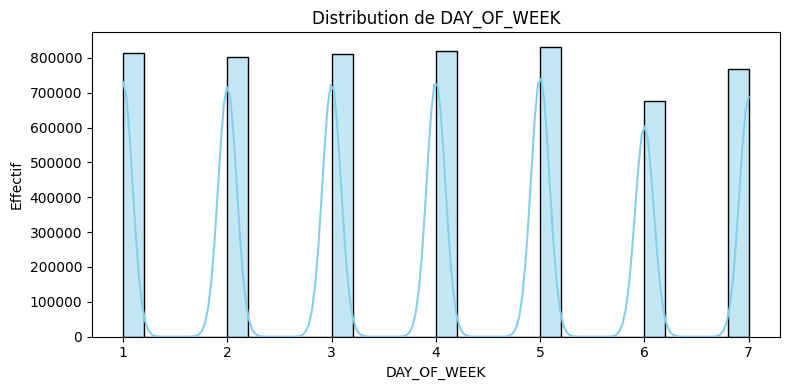

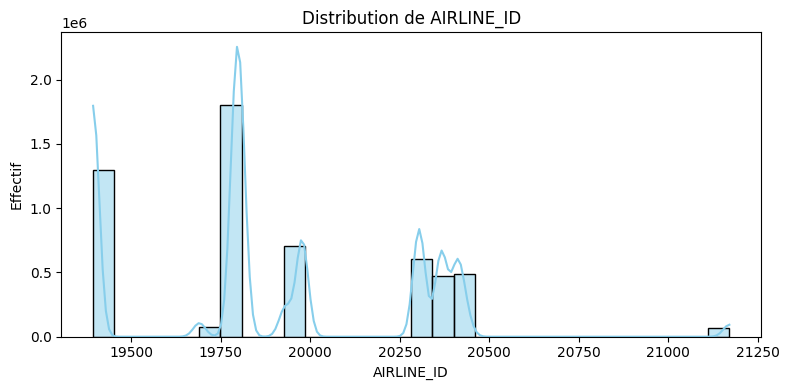

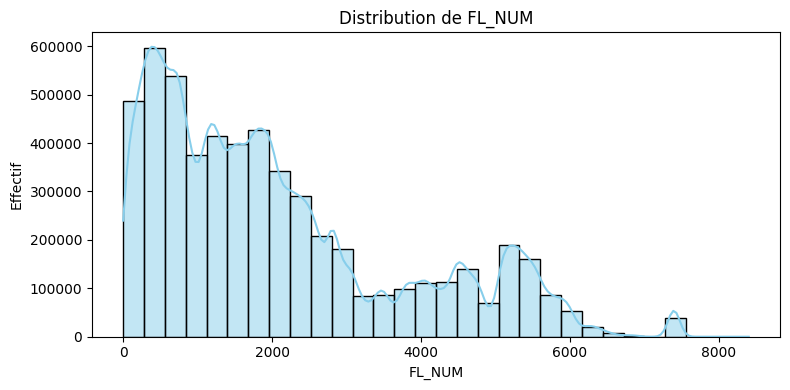

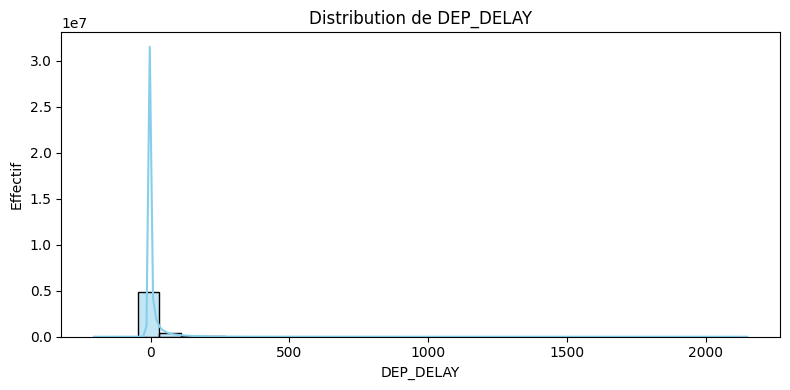

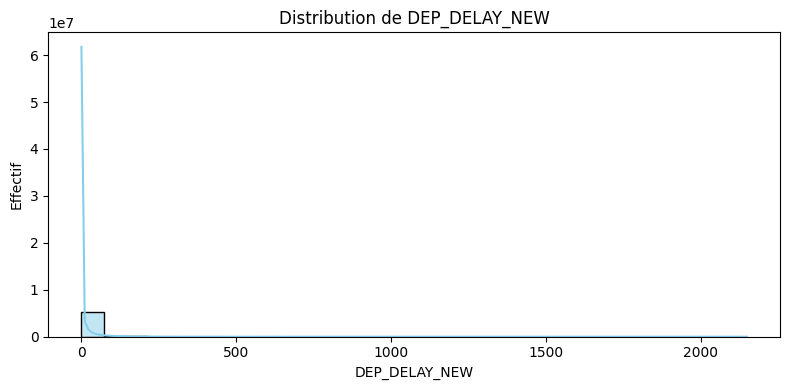

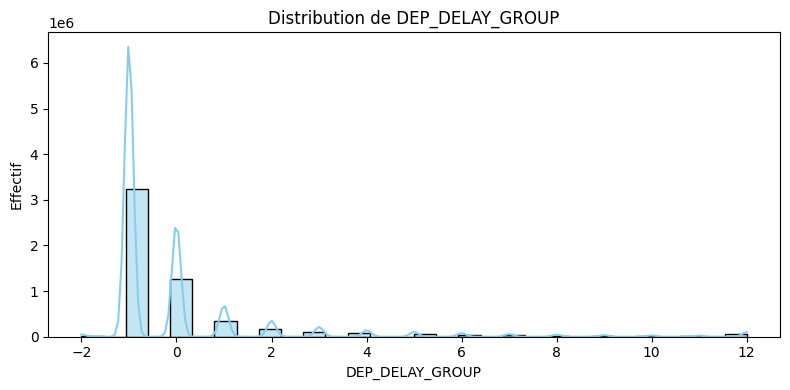

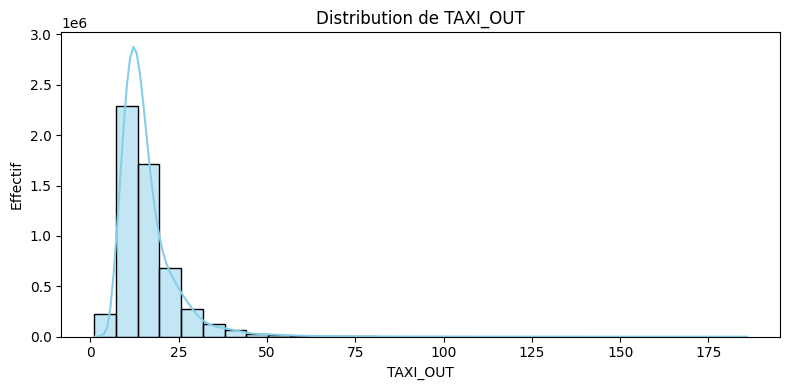

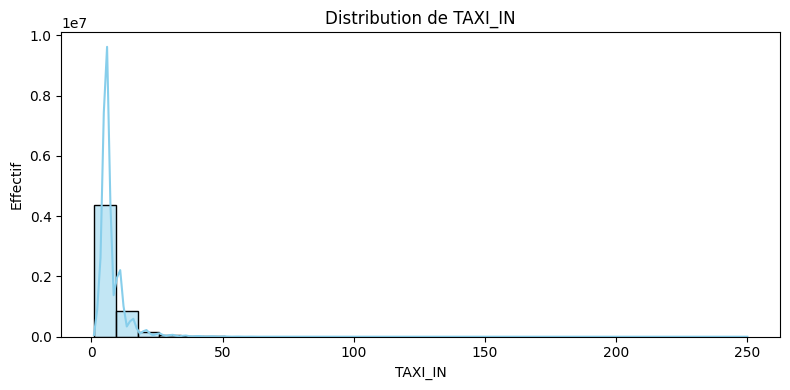

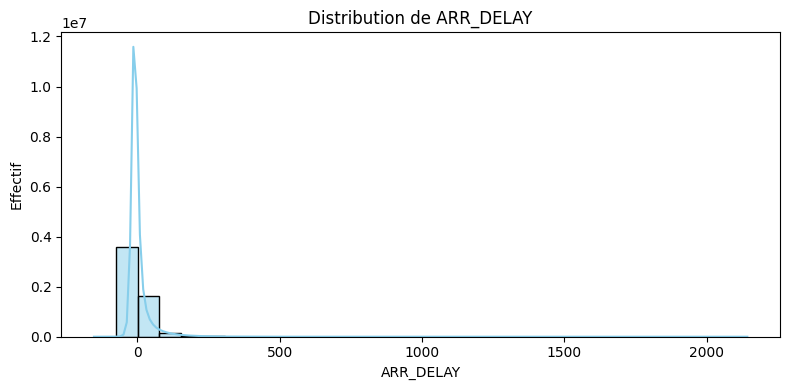

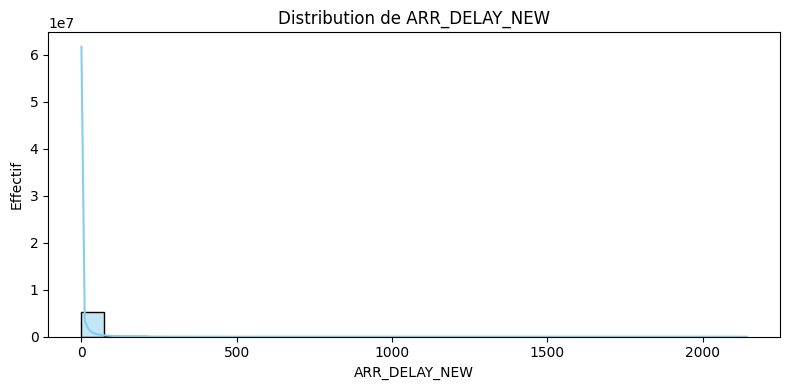

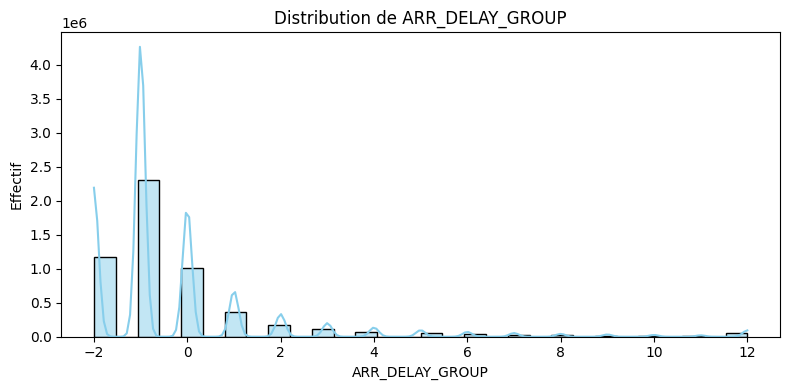

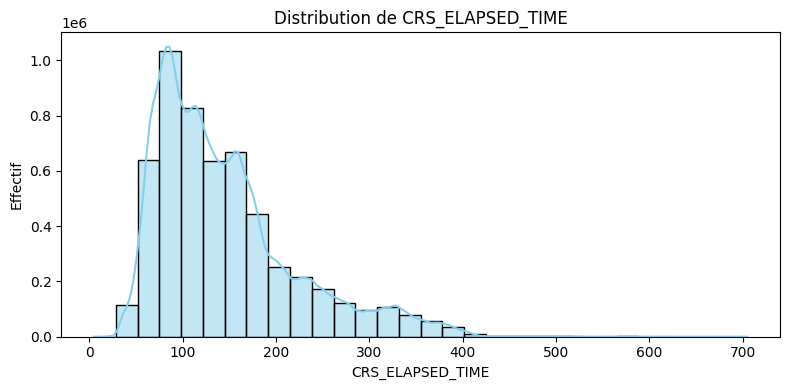

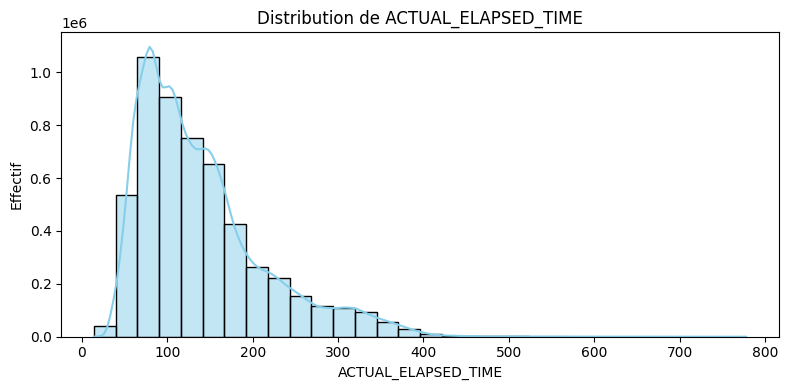

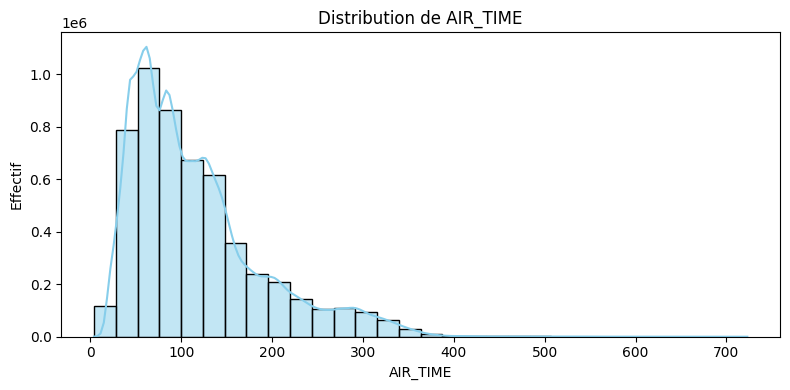

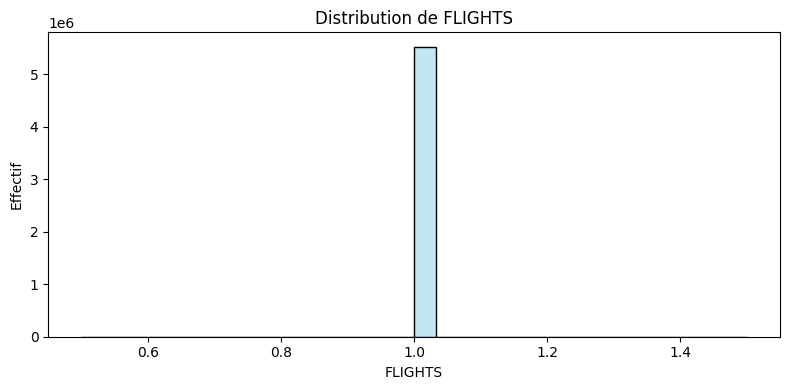

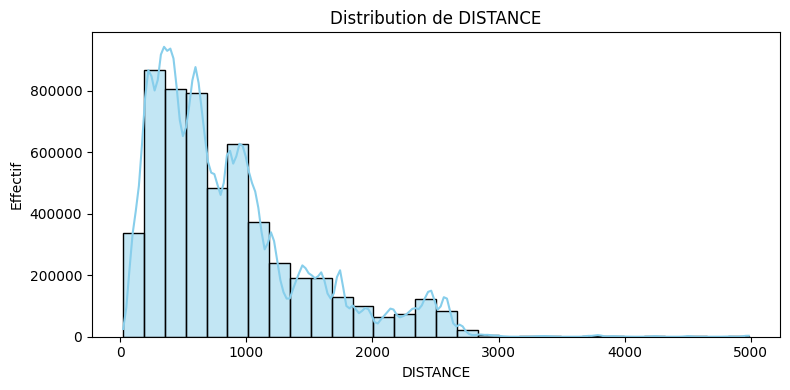

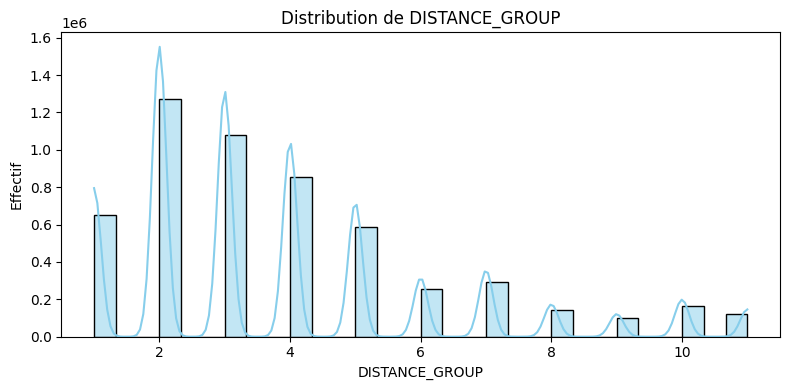

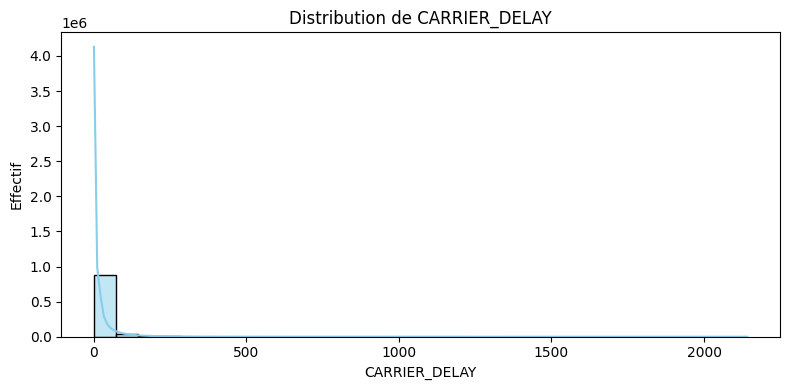

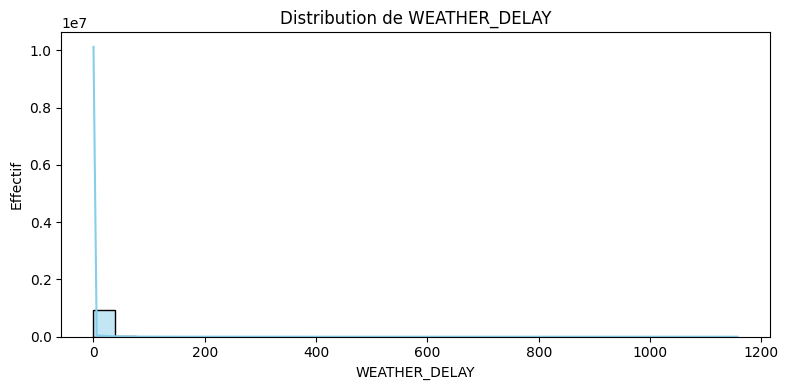

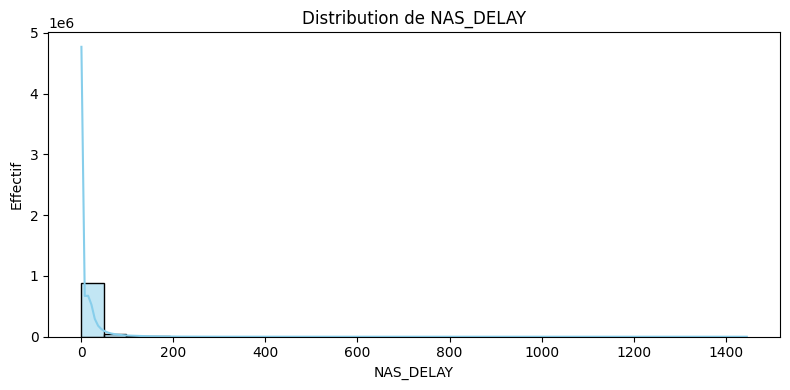

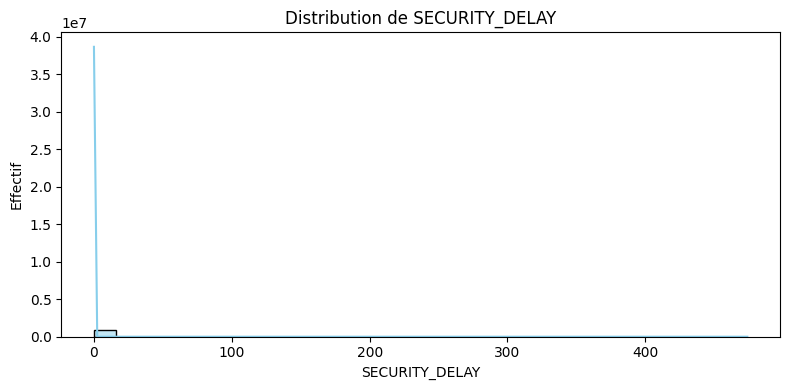

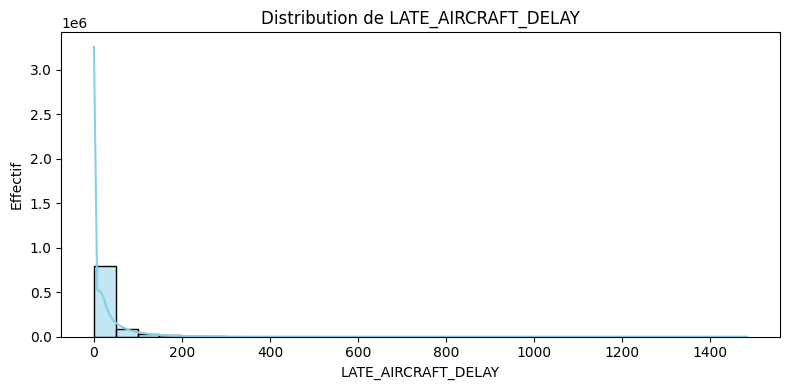

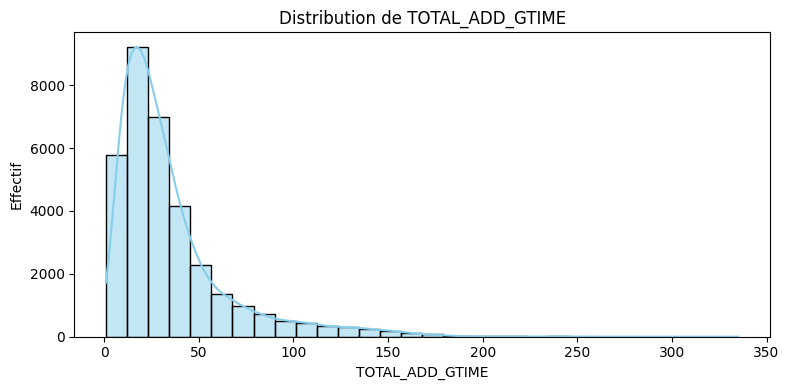

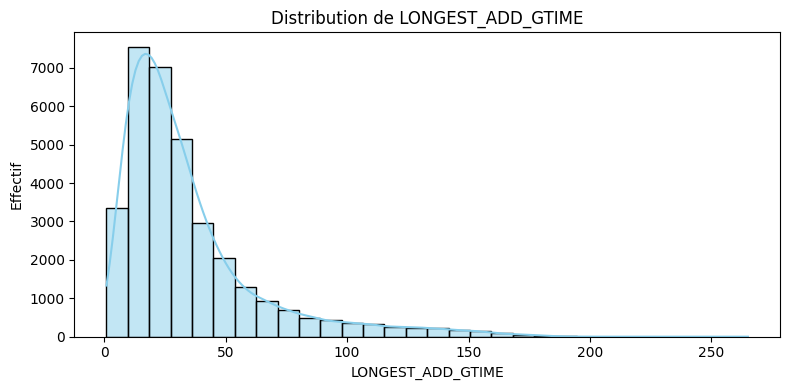

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
# num_cols = df_clean.select_dtypes(include=['int64', 'float64']).columns
# print(f"Colonnes numériques : {num_cols.tolist()}")
# Visualisation des distributions
for col in num_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(df_clean[col].dropna(), bins=30, kde=True, color='skyblue')
    plt.title(f"Distribution de {col}")
    plt.xlabel(col)
    plt.ylabel("Effectif")
    plt.tight_layout()
    plt.show()

<Axes: >

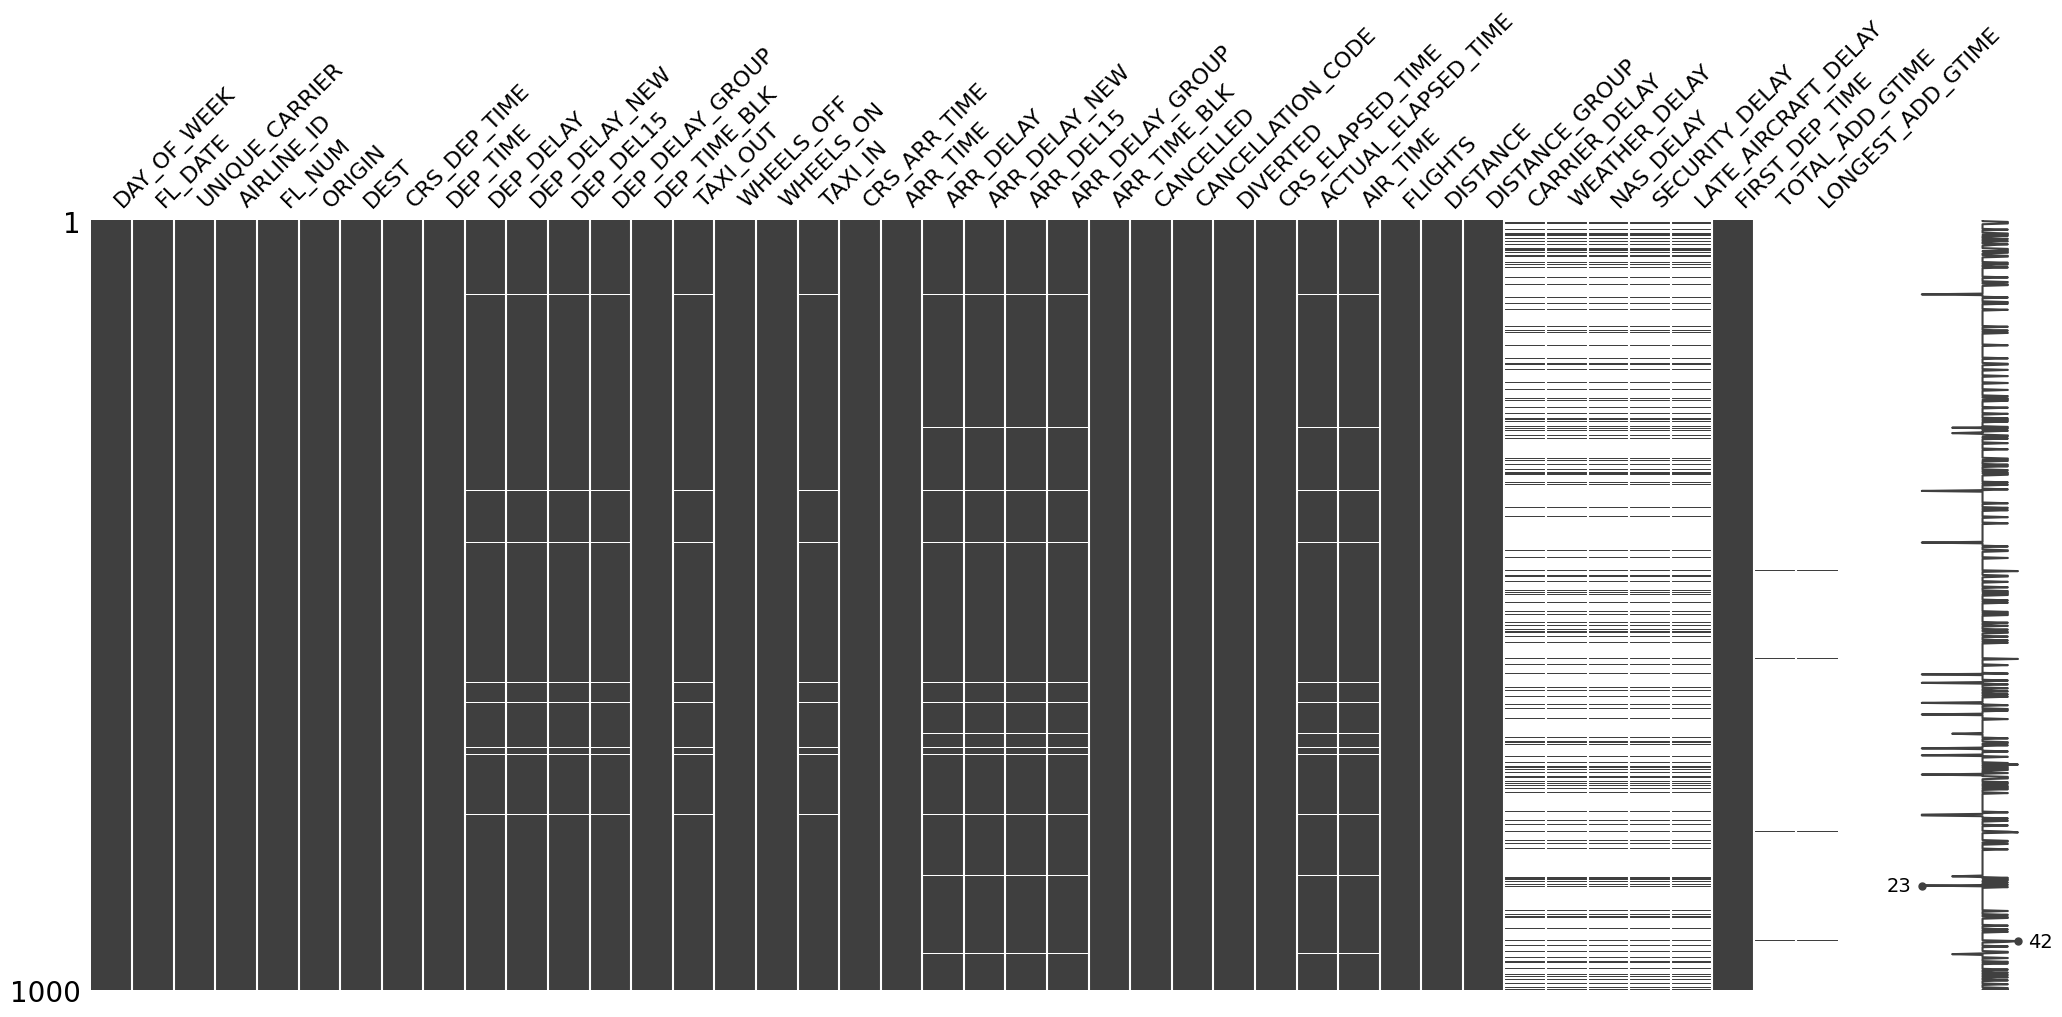

In [8]:
# %pip install missingno
import missingno as msno
%matplotlib inline
msno.matrix(df_clean.sample(1000))

In [6]:
# Nombre de valeurs non nulles par colonne
import pandas as pd

clean_path = "data/processed/all_cleaned.parquet"
df_clean = pd.read_parquet(clean_path)

val_counts = df_clean.count().sort_values(ascending=False)
display(val_counts.to_frame(name="nb_valeurs_non_nulles"))

,nb_valeurs_non_nulles
DAY_OF_WEEK,5518856
FL_DATE,5518856
UNIQUE_CARRIER,5518856
AIRLINE_ID,5518856
FL_NUM,5518856
ORIGIN,5518856
DEST,5518856
CRS_DEP_TIME,5518856
DEP_TIME,5518856
DEP_TIME_BLK,5518856


In [7]:
# Nombre de valeurs distinctes (uniques) par colonne
import pandas as pd

clean_path = "data/processed/all_cleaned.parquet"
df_clean = pd.read_parquet(clean_path)

unique_counts = df_clean.nunique(dropna=True).sort_values(ascending=False)
display(unique_counts.to_frame(name="nb_valeurs_uniques"))

,nb_valeurs_uniques
FL_NUM,6974
DEP_TIME,1441
WHEELS_OFF,1441
ARR_TIME,1441
WHEELS_ON,1441
CRS_ARR_TIME,1439
ARR_DELAY,1386
DISTANCE,1364
DEP_DELAY,1337
CRS_DEP_TIME,1334


In [9]:
# Sauvegarde d'un échantillon de 1000 lignes en CSV
import pandas as pd

clean_path = "data/processed/all_cleaned.parquet"
df_clean = pd.read_parquet(clean_path)

sample_1000 = df_clean.sample(n=1000, random_state=42)
sample_1000.to_csv("data/processed/sample_1000.csv", index=False)
print("✅ Échantillon de 1000 lignes sauvegardé dans data/processed/sample_1000.csv")

✅ Échantillon de 1000 lignes sauvegardé dans data/processed/sample_1000.csv


In [10]:
# Estimation du volume de valeurs manquantes (NaN) par colonne et au total
import pandas as pd

clean_path = "data/processed/all_cleaned.parquet"
df_clean = pd.read_parquet(clean_path)

missing_per_col = df_clean.isna().sum().sort_values(ascending=False)
total_missing = missing_per_col.sum()
print("Nombre de valeurs manquantes par colonne :")
display(missing_per_col.to_frame(name="nb_nan"))
print(f"\nNombre total de valeurs manquantes dans le DataFrame : {total_missing}")

Nombre de valeurs manquantes par colonne :


,nb_nan
LONGEST_ADD_GTIME,5485048
TOTAL_ADD_GTIME,5485048
SECURITY_DELAY,4568711
NAS_DELAY,4568711
WEATHER_DELAY,4568711
CARRIER_DELAY,4568711
LATE_AIRCRAFT_DELAY,4568711
ARR_DEL15,78708
ARR_DELAY_GROUP,78708
ACTUAL_ELAPSED_TIME,78708



Nombre total de valeurs manquantes dans le DataFrame : 34669231


- DEP_DELAY_GROUP et DEP_DELAY_NEW sont redondant
-  On des missing data
-  on va virer : 
LONGEST_ADD_GTIME	5485048
TOTAL_ADD_GTIME	5485048

In [18]:
df_clean.describe()

,DAY_OF_WEEK,FL_DATE,UNIQUE_CARRIER,AIRLINE_ID,FL_NUM,ORIGIN,DEST,CRS_DEP_TIME,DEP_TIME,DEP_DELAY,...,DISTANCE,DISTANCE_GROUP,CARRIER_DELAY,WEATHER_DELAY,NAS_DELAY,SECURITY_DELAY,LATE_AIRCRAFT_DELAY,FIRST_DEP_TIME,TOTAL_ADD_GTIME,LONGEST_ADD_GTIME
count,5518856,5518856,5518856,5518856,5518856,5518856,5518856,5518856,5518856,5518856,...,5518856,5518856,5518856,5518856,5518856,5518856,5518856,5518856,5518856,5518856
unique,7,366,12,12,6974,313,310,1334,1441,1338,...,1364,11,1208,689,609,173,750,1294,236,203
top,5,2016-11-27,WN,19393,511,ATL,ATL,0600,,-3.00,...,337.00,2,,,,,,,,
freq,831354,17065,1296854,1296854,3903,378292,378050,96191,62840,444621,...,53675,1273422,4568711,4568711,4568711,4568711,4568711,5485048,5485048,5485048
